In [46]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# load dataset
df = pd.read_csv("Iris.csv")

In [48]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [49]:
# UNDERSTAND DATASET

In [50]:
df.shape

(150, 6)

In [51]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [53]:
df.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [54]:
# DATA QUALITY CHECK

In [55]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
# TARGET VARIABLE

In [58]:
# Looking into what classes our model will predict
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [59]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [60]:
# STATISTICAL ANALYSIS

In [61]:
# Basic Statistical Analysis
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [62]:
# Seeing how measurement between species varies
df.groupby("Species").mean(numeric_only=True)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


In [63]:
# DATA VISUALIZATION

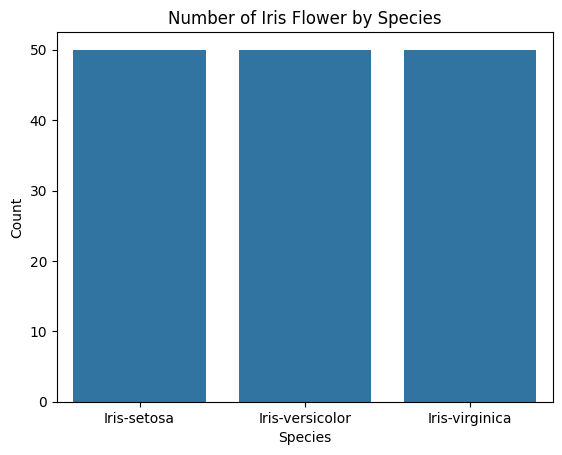

In [64]:
# Distribution of Three classes / Species Count
sns.countplot(data = df, x = 'Species')

plt.title("Number of Iris Flower by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

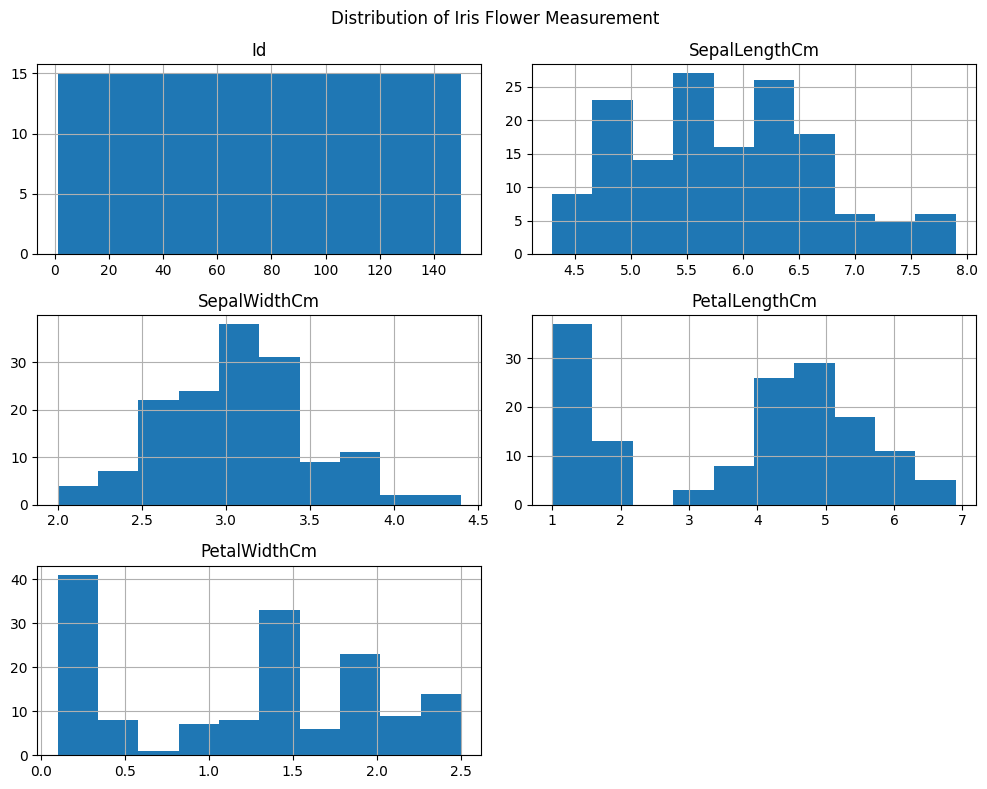

In [65]:
# Feature distribution
df.hist(figsize=(10, 8))

plt.suptitle("Distribution of Iris Flower Measurement")
plt.tight_layout()
plt.show()

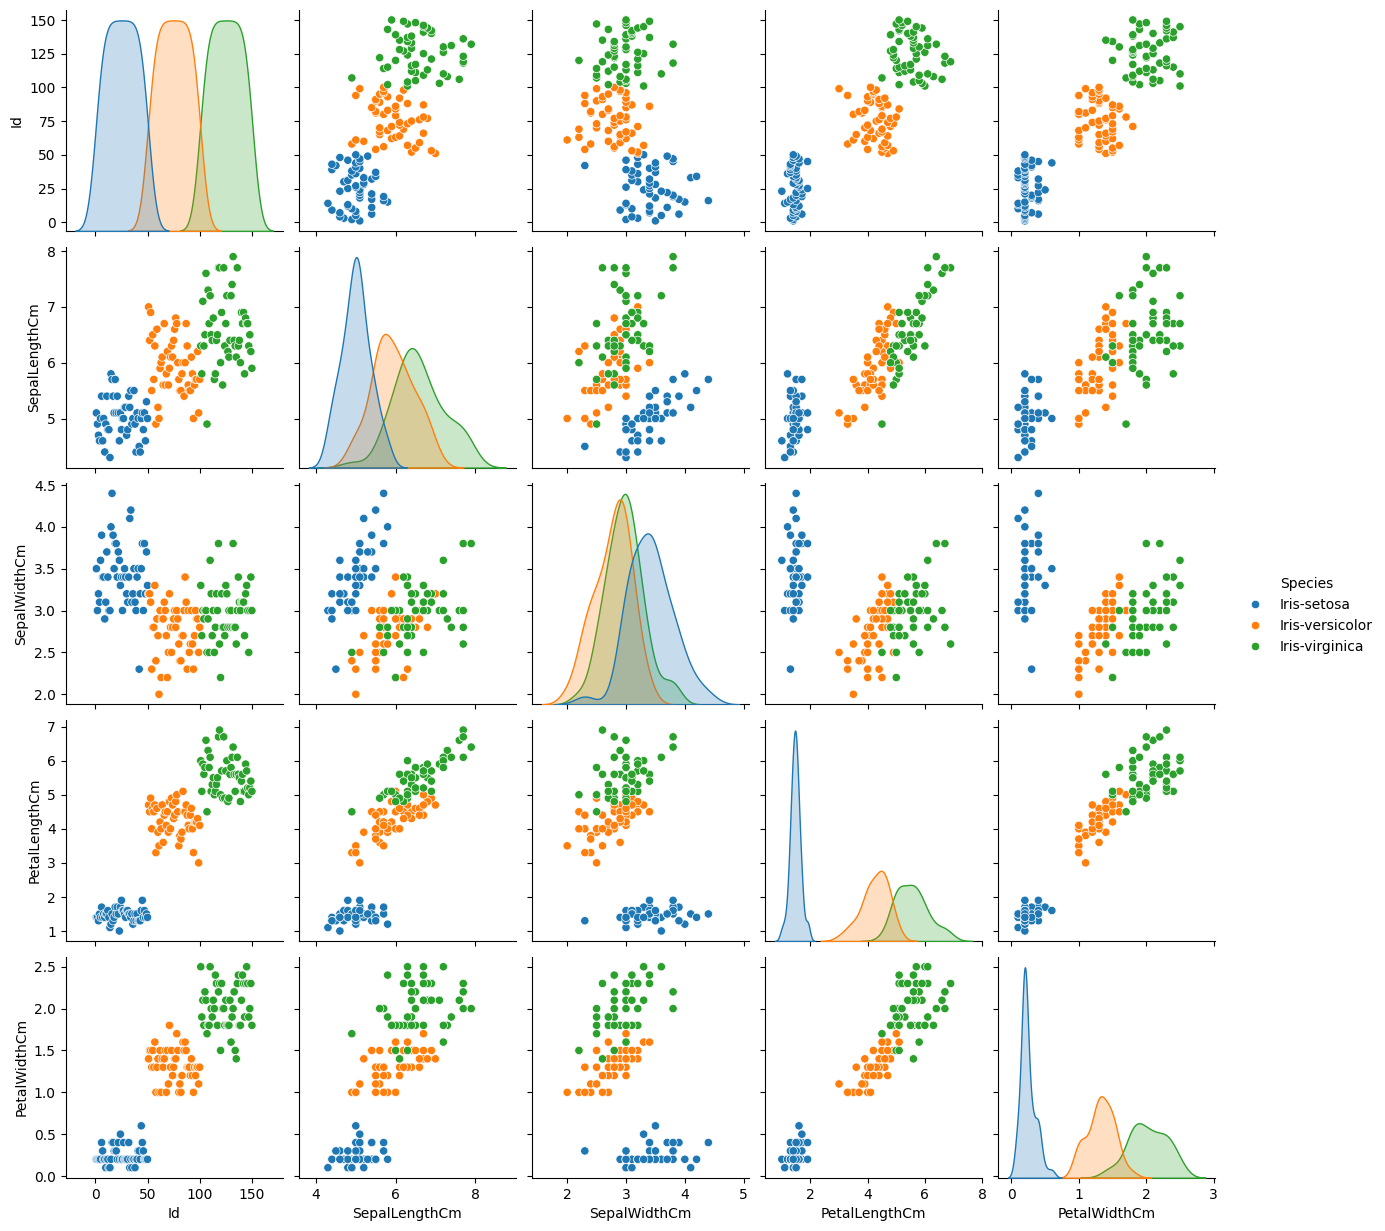

In [66]:
sns.pairplot(df, hue='Species')

plt.show()

In [67]:
# CORRELATION ANALYSIS

In [68]:
correlation = df.select_dtypes(include=['float64', 'int64']).corr()

print(correlation)

                     Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Id             1.000000       0.716676     -0.397729       0.882747   
SepalLengthCm  0.716676       1.000000     -0.109369       0.871754   
SepalWidthCm  -0.397729      -0.109369      1.000000      -0.420516   
PetalLengthCm  0.882747       0.871754     -0.420516       1.000000   
PetalWidthCm   0.899759       0.817954     -0.356544       0.962757   

               PetalWidthCm  
Id                 0.899759  
SepalLengthCm      0.817954  
SepalWidthCm      -0.356544  
PetalLengthCm      0.962757  
PetalWidthCm       1.000000  


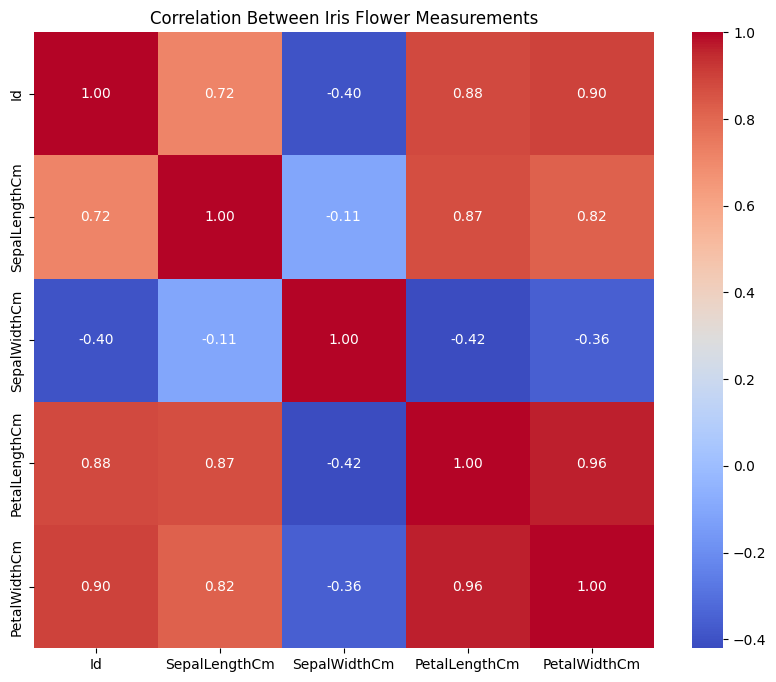

In [69]:
plt.figure(figsize=(10, 8))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Between Iris Flower Measurements")
plt.show()

In [83]:
# DATA PREPROCESSING

In [70]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [84]:
# X = features, y = target
X=df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]
y=df["Species"]

In [72]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [73]:
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [85]:
#TRAIN-TEST SPLIT

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [86]:
# MODEL TRAINING

In [77]:
from sklearn.tree import DecisionTreeClassifier

In [78]:
model = DecisionTreeClassifier(random_state=42)

In [79]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

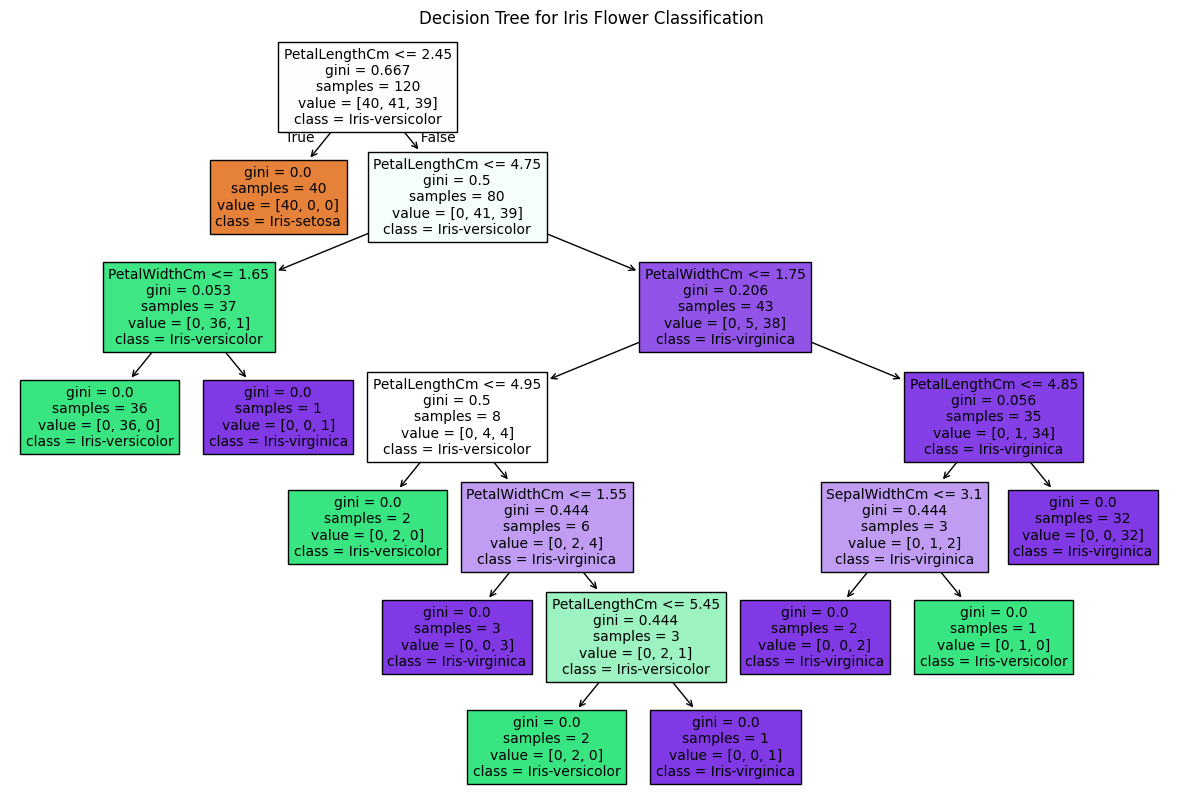

In [98]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("Decision Tree for Iris Flower Classification")
plt.show()

In [92]:
# PREDICTIONS
# finding predictions by providing the test features
y_pred = model.predict(X_test)

In [91]:
# ACTUAL VS PREDICTED
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.head(10)

,Actual,Predicted
73,Iris-versicolor,Iris-versicolor
18,Iris-setosa,Iris-setosa
118,Iris-virginica,Iris-virginica
78,Iris-versicolor,Iris-versicolor
76,Iris-versicolor,Iris-versicolor
31,Iris-setosa,Iris-setosa
64,Iris-versicolor,Iris-versicolor
141,Iris-virginica,Iris-virginica
68,Iris-versicolor,Iris-versicolor
82,Iris-versicolor,Iris-versicolor


In [94]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


In [95]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [96]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


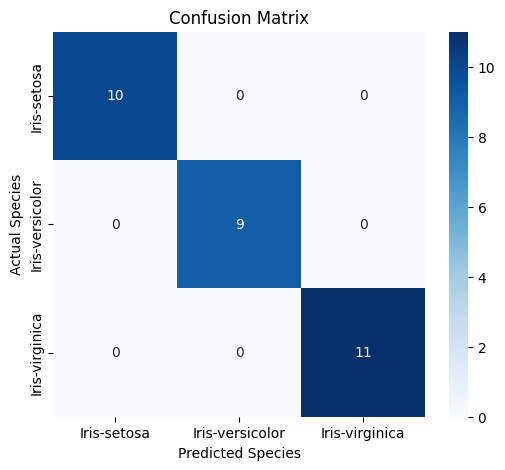

In [97]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

## Conclusion

In this project, a Decision Tree Classifier was developed to classify
Iris flowers into three species: Setosa, Versicolor, and Virginica.

The dataset was explored and prepared by separating the flower
measurements into input features and the species into the target variable.
The data was divided into training and testing sets using an 80:20 split.

The Decision Tree model was trained using the training data and evaluated
on the unseen test data using accuracy, precision, recall, F1-score, and
a confusion matrix.

The model achieved a test accuracy of 100%.

The confusion matrix was used to identify correctly classified samples
and any instances where the model confused one Iris species with another.

Overall, this project demonstrates the basic workflow of a supervised
machine learning classification problem, from data exploration and
preprocessing to model training, prediction, and evaluation.